In [1]:
import os
import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import time
import tm
import tqdm
import copy
import sys
import datasetutils
plt.style.use('dark_background') # i prefer this color scheme but need to install. coment if not working

In [2]:
#import importlib
#importlib.reload(tm)

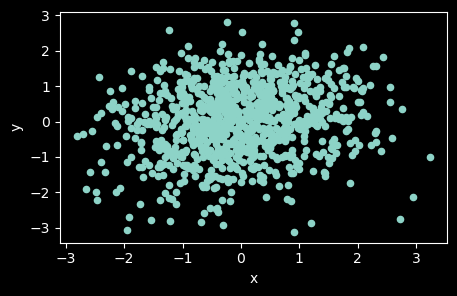

In [2]:
# 1 - CREATE DATA
# the idea is to create a dataframe with variables started with x and target returns started with y
# columns then can be x1, x_1, x2, xsomething ... and y1, y, y2, y_3
# index should be a datetime 
# this is the part where we spend most time researching :)
# lets generate some synthetic data 
n = 1000
x = np.random.normal(0, 1, n)
a = 0
b = 0.2
y = a+b*x+np.random.normal(0,1,n)
df1 = pd.DataFrame()
df1['x'] = x
df1['y'] = y
df1.index = pd.date_range('2000-01-01', freq = 'D', periods = n)
df1.plot.scatter('x', 'y')
plt.show()


In [6]:
df1['x2'] = 5
df1['z1'] = 1
df1['z2'] = 2
df1

,x,y,x2,z1,z2
2000-01-01,-0.954746,0.277734,5,1,2
2000-01-02,0.377586,-1.576047,5,1,2
2000-01-03,0.102301,-0.216018,5,1,2
2000-01-04,1.741074,0.001069,5,1,2
2000-01-05,0.605113,-0.479404,5,1,2
...,...,...,...,...,...
2002-09-22,0.453367,-0.213112,5,1,2
2002-09-23,1.077528,0.698077,5,1,2
2002-09-24,0.556516,0.028831,5,1,2
2002-09-25,-1.079649,0.905794,5,1,2


In [8]:
tmp = tm.Data.from_df(df1)
tmp2 = tmp._get_columns(['y', 'x', 'z1'])
tmp2

                   y         x   z1  msidx    s   pw  w_y
2000-01-01  0.277734 -0.954746  1.0    0.0  0.0  1.0  0.0
2000-01-02 -1.576047  0.377586  1.0    0.0  0.0  1.0  0.0
2000-01-03 -0.216018  0.102301  1.0    0.0  0.0  1.0  0.0
2000-01-04  0.001069  1.741074  1.0    0.0  0.0  1.0  0.0
2000-01-05 -0.479404  0.605113  1.0    0.0  0.0  1.0  0.0
...              ...       ...  ...    ...  ...  ...  ...
2002-09-22 -0.213112  0.453367  1.0    0.0  0.0  1.0  0.0
2002-09-23  0.698077  1.077528  1.0    0.0  0.0  1.0  0.0
2002-09-24  0.028831  0.556516  1.0    0.0  0.0  1.0  0.0
2002-09-25  0.905794 -1.079649  1.0    0.0  0.0  1.0  0.0
2002-09-26 -2.468010 -0.432659  1.0    0.0  0.0  1.0  0.0

[1000 rows x 7 columns]

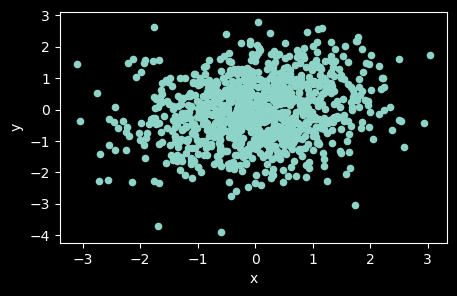

,y,x
2002-01-01,0.444870,-0.280852
2002-01-02,0.897053,0.331553
2002-01-03,0.596130,0.341051
2002-01-04,-0.141688,0.348679
2002-01-05,-0.221171,-0.665060
...,...,...
2004-09-22,-1.500436,-1.291746
2004-09-23,-0.342208,0.187116
2004-09-24,-0.757740,1.031517
2004-09-25,-3.903283,-0.591627


In [13]:
# 1 - CREATE DATA
# the idea is to create a dataframe with variables started with x and target returns started with y
# columns then can be x1, x_1, x2, xsomething ... and y1, y, y2, y_3
# index should be a datetime 
# this is the part where we spend most time researching :)
# lets generate some synthetic data 
n = 1000
x = np.random.normal(0, 1, n)
a = 0
b = 0.2
y = a+b*x+np.random.normal(0,1,n)
df2 = pd.DataFrame()
df2['y'] = y
df2['x'] = x
df2.index = pd.date_range('2002-01-01', freq = 'D', periods = n)
df2.plot.scatter('x', 'y')
plt.show()
df2

In [21]:
def extract_prefix(name):
    return ''.join(filter(str.isalpha, name))
columns = sorted(['x1', 'y', 'z', 'x2'], key=extract_prefix)
columns

['x1', 'x2', 'y', 'z']

In [22]:
SEPARATOR_VARIABLES = '_'
def contiguous_prefix_slices(columns: np.ndarray):
    columns = [c.split(SEPARATOR_VARIABLES)[0] for c in columns] # added this
    prefixes = [''.join(filter(str.isalpha, name)) for name in columns]
    result = {}
    i = 0
    while i < len(columns):
        prefix = prefixes[i]
        start = i
        while i < len(columns) and prefixes[i] == prefix:
            i += 1
        result[prefix] = slice(start, i)
    return result


prefix_slices = contiguous_prefix_slices(columns)
prefix_slices

{'x': slice(0, 2, None), 'y': slice(2, 3, None), 'z': slice(3, 4, None)}

In [23]:
columns[prefix_slices['x']]

['x1', 'x2']

In [24]:
req_x = ['x1', 'x3']
x = ['x1', 'x2', 'x3']
[x.index(v) for v in req_x]


[0, 2]

In [5]:
#%load_ext autoreload
#%autoreload 2

In [6]:
#import importlib
#importlib.reload(tm)

In [7]:
# 2 - CREATE TM OBJECTS



dataset = tm.Dataset()
dataset.add('strat1', df1)
dataset.add('strat2', df2)

ensemble_model = tm.ensemble.InvVolEnsembleModel()
base_model = tm.base.LinRegr()
alloc = tm.allocation.Optimal(c = None)
model = tm.Model(base_model = base_model, allocation = alloc)    

master_models_map = [
        {'master_model':model, 
         'apply_to':['strat1', 'strat2'], 
         'columns':['y1', 'x1','x2','z1']}
        ] 

model_set = tm.ModelSet(ensemble_model = ensemble_model, master_models_map = master_models_map)     

model_set.estimate(dataset)
model_set.view()



******* ModelSet *******

EnsembleModel
Portfolio Weight for strat1 = 0.5062565933815002
Portfolio Weight for strat2 = 0.49374340661849986


-> For key strat1
* Model *
** Linear Regression **
Weights:  [-0.0360749   0.21358149]
Variance:  0.9835322122040671


Weight norm:  0.3582816802600815
Weight mean:  -0.02703176272200793



-> For key strat2
* Model *
** Linear Regression **
Weights:  [-0.0360749   0.21358149]
Variance:  0.9835322122040671


Weight norm:  0.3582816802600815
Weight mean:  -0.02703176272200793


*************************


In [8]:
# 3 - RUN CVBT
# this part is always the same and is easy
paths = tm.cvbt(
        dataset = dataset, 
        modelset = model_set,            
        n_paths = 5,
        k_folds = 4, 
        seq_path = False, 
        start_fold = 0, 
        burn_fraction = 0.1, 
        min_burn_points = 3,
        view_after_estimate = False
        )


100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 80.52it/s]


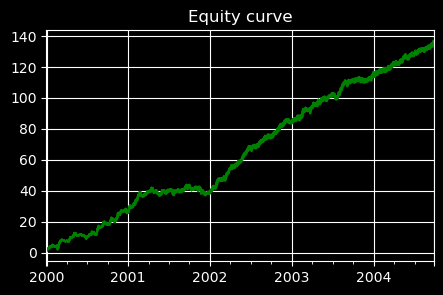

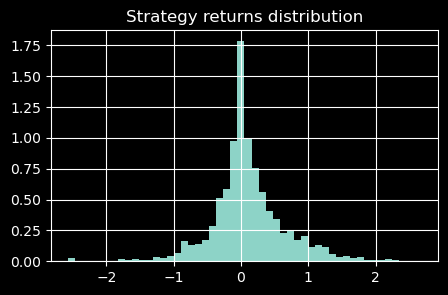

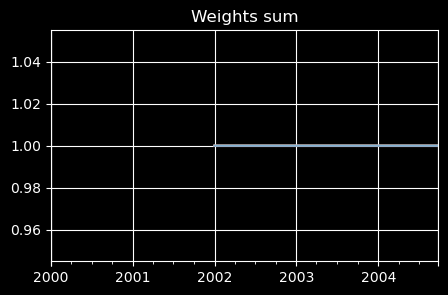

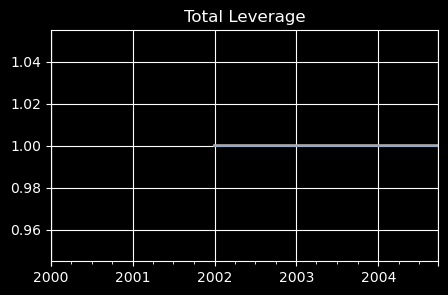

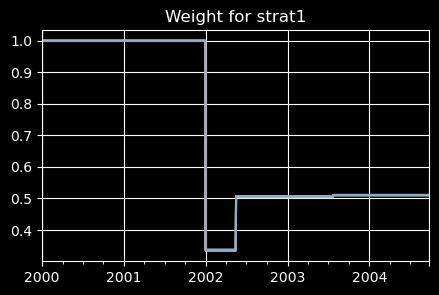

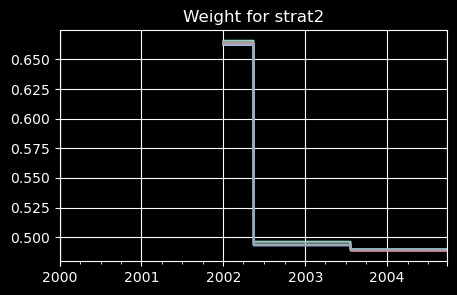

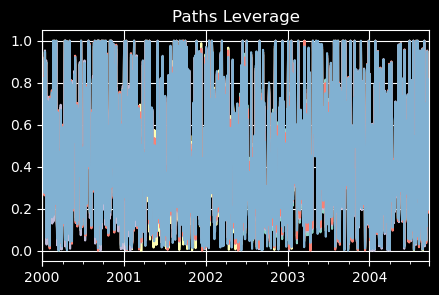

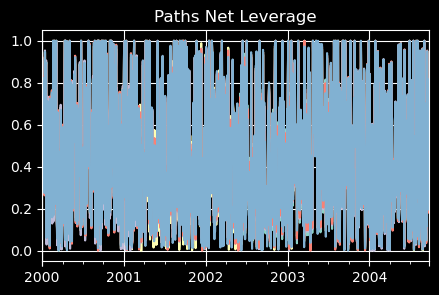

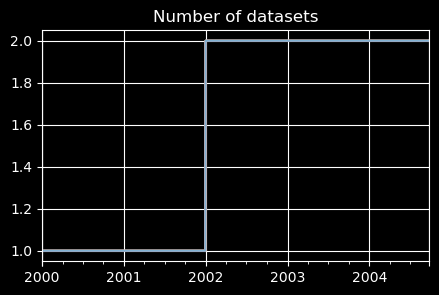

** ACCEPT STRATEGY from normal approximation of bootstrap Sharpe [alpha = 5e-05]**


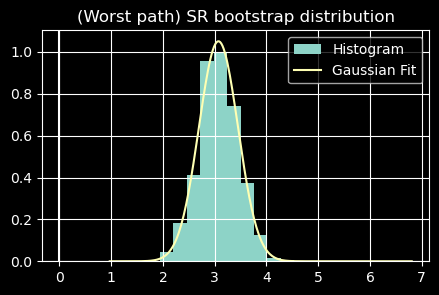


** PERFORMANCE SUMMARY **

Return:  27.516287495185594
Standard deviation:  8.693665946606346
Sharpe:  3.165096020963036



,path_1,path_2,path_3,path_4,path_5
1999-12-31,1.292280,1.267669,1.235878,1.293868,1.278642
2000-01-03,0.305694,0.300201,0.294077,0.306218,0.303759
2000-01-04,-0.038765,-0.041178,-0.043631,-0.037615,-0.039107
2000-01-05,0.434488,0.424998,0.411559,0.435107,0.427961
2000-01-06,0.586757,0.560000,0.522404,0.591699,0.569667
...,...,...,...,...,...
2004-09-20,-0.045376,-0.046642,-0.049353,-0.044057,-0.047705
2004-09-21,-0.177551,-0.175863,-0.170462,-0.179529,-0.174663
2004-09-22,0.319041,0.318223,0.313798,0.320251,0.317720
2004-09-23,1.789110,1.801751,1.818584,1.777471,1.812630


In [9]:
paths.portfolio_post_process(pct_fee = 0)
